### 1. Аналитическое решение задачи регрессии (в векторной форме)

Для модели $y = Xw$ (без смещения, или со смещением как столбцом единиц) и MSE-лосса:

$$L(w) = \frac{1}{N} \|y - Xw\|^2$$

Берём градиент и приравниваем к нулю:

$$\nabla_w L = -\frac{2}{N} X^T(y - Xw) = 0$$

Умножаем на $-N/2$:

$$X^T y - X^T X w = 0$$

**Аналитическое решение** получается из **метода наименьших квадратов** и приводит к **нормальному уравнению**:

$$\boxed{w = (X^T X)^{-1} X^T y}$$

**Проблема**: обращение матрицы $X^T X$ имеет сложность $O(D^3)$, где $D$ — число признаков. При $D > 10^4$ это становится невозможным.

---

### 2. Что меняется при добавлении L1 и L2 регуляризации

**L2-регуляризация (Ridge)**:

$$L_{ridge}(w) = \|y - Xw\|^2 + \lambda \|w\|_2^2$$

Аналитическое решение:

$$w = (X^T X + \lambda I)^{-1} X^T y$$

- Добавка $\lambda I$ делает матрицу обратимой всегда (даже если $X^T X$ вырождена)
- Все веса **сжимаются к нулю**, но редко становятся точно нулевыми

**L1-регуляризация (Lasso)**:

$$L_{lasso}(w) = \|y - Xw\|^2 + \lambda \|w\|_1$$

- Аналитического решения нет (из-за недифференцируемости в нуле)
- Решается через **субградиентный спуск** или координатный спуск
- L1 **обнуляет** неважные признаки — возникает разреженность

---

### 3. Почему L1 используется для отбора признаков

Геометрическая интуиция:

- **L1** — шар в виде ромба (в 2D — квадрат, повёрнутый на 45°)
- **L2** — шар в виде круга (в 2D — окружность)

При минимизации $\|y-Xw\|^2 + \lambda\|w\|_1$ оптимум часто попадает на **угол** ромба, где некоторые координаты равны нулю.

**Пример**: если признак не влияет на ошибку, выгоднее обнулить его (сэкономить $\lambda$), чем держать маленьким, как в L2.

---

### 4. Как моделировать нелинейные зависимости с помощью линейных моделей

**Идея**: заменить исходные признаки $x$ на **полиномиальные** или другие базисные функции $\phi(x)$.

**Пример**: для одномерного $x$:

1. **Полиномиальные признаки:** $\phi(x) = [1, x, x^2, x^3, ...]$
2. **Базисные функции (сплайны):**
   $$\phi_j(x) = \max(0, x - t_j)$$

3. **Ядерный трюк:** $f(x) = \sum_{i=1}^N \alpha_i K(x, x_i)$

4. **Преобразование признаков:**
   - $\log(x)$, $\sqrt{x}$, $e^x$
   - Взаимодействия: $x_i \cdot x_j$

Модель становится:

$$f(x) = w_0 + w_1 x + w_2 x^2 + \dots + w_d x^d$$

В коде это делается через `PolynomialFeatures` из sklearn. При этом модель **остаётся линейной по параметрам $w$**, но может аппроксимировать любые нелинейные функции.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
import json
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler, StandardScaler, PolynomialFeatures
from sklearn.linear_model import LinearRegression, Ridge, Lasso, ElasticNet
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [2]:
data = pd.read_json('data/train.json')

print(f"Train shape: {data.shape}")
print(data.head(2))

Train shape: (49352, 15)
   bathrooms  bedrooms                       building_id              created  \
4        1.0         1  8579a0b0d54db803821a35a4a615e97a  2016-06-16 05:55:27   
6        1.0         2  b8e75fc949a6cd8225b455648a951712  2016-06-01 05:44:33   

                                         description      display_address  \
4  Spacious 1 Bedroom 1 Bathroom in Williamsburg!...  145 Borinquen Place   
6  BRAND NEW GUT RENOVATED TRUE 2 BEDROOMFind you...            East 44th   

                                            features  latitude  listing_id  \
4  [Dining Room, Pre-War, Laundry in Building, Di...   40.7108     7170325   
6  [Doorman, Elevator, Laundry in Building, Dishw...   40.7513     7092344   

   longitude                        manager_id  \
4   -73.9539  a10db4590843d78c784171a107bdacb4   
6   -73.9722  955db33477af4f40004820b4aed804a0   

                                              photos  price  \
4  [https://photos.renthop.com/2/7170325_3bb5ac84.

In [3]:
upper_perc = np.percentile(data['price'], 99)
lower_perc = np.percentile(data['price'], 1)

data = data[(data['price'] < upper_perc) & (data['price'] > lower_perc)]
data = data.reset_index(drop=True)

In [4]:
data['interest_level'] = data['interest_level'].map({'low': 0, 'medium' : 1, 'high' : 2})

In [5]:
data['features'] = data['features'].apply(
    lambda x: [item.replace('[', '').replace(']', '').replace("'", "").replace('"', '').replace(' ', '')
               for item in x]
)

In [6]:
all_features = []
for idx, row in data.iterrows():
    all_features.extend(row['features'])
print(f"Всего записей в списке признаков: {len(all_features)}")
print(f"Уникальных признаков: {len(set(all_features))}")

Всего записей в списке признаков: 262377
Уникальных признаков: 1529


In [7]:
feature_counts = Counter(all_features)
top_20 = [item for item, count in feature_counts.most_common(20)]
print(top_20)

['Elevator', 'HardwoodFloors', 'CatsAllowed', 'DogsAllowed', 'Doorman', 'Dishwasher', 'NoFee', 'LaundryinBuilding', 'FitnessCenter', 'Pre-War', 'LaundryinUnit', 'RoofDeck', 'OutdoorSpace', 'DiningRoom', 'HighSpeedInternet', 'Balcony', 'SwimmingPool', 'LaundryInBuilding', 'NewConstruction', 'Terrace']


In [8]:
for feature in top_20:
    data[feature] = data['features'].apply(lambda x: 1 if feature in x else 0)

In [9]:
feature_list = ['bathrooms', 'bedrooms'] + top_20
print(f"\nВсего признаков: {len(feature_list)}")

X = data[feature_list]
y = data['price']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=21)

print(f"\nРазмер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки: {X_test.shape}")


Всего признаков: 22

Размер обучающей выборки: (38674, 22)
Размер тестовой выборки: (9669, 22)


In [10]:
# Реализация моделей
class LinearRegressionSGD:
  def __init__(self, learning_rate=0.01, n_iterations=1000, batch_size=32, random_state=42):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.batch_size = batch_size
        self.random_state = random_state
        self.weights = None
        self.bias = None
        self.loss_history = []

  def _add_bias(self, X):
        return np.c_[np.ones(X.shape[0]), X]

  # делаем детерминированной - фиксированный порядок объектов, получаем всегда одинаковый результат
  def fit(self, X, y, deterministic=True):
        np.random.seed(self.random_state)
        X = np.array(X)
        y = np.array(y).reshape(-1, 1) # делаем столбец

        n_samples, n_features = X.shape
        # уменьшаем в 100 раз для стабильности, сходимости, предотвращения взрыва градиента и переполнения
        self.weights = np.random.randn(n_features, 1) * 0.01
        # (1, 1) - broadcasting автоматически добавит bias к каждой строке
        self.bias = np.zeros((1, 1))

        for iteration in range(self.n_iterations):
            if deterministic:
                indices = np.arange(n_samples)
            else:
                indices = np.random.permutation(n_samples)

            epoch_loss = 0

            # Mini-batch SGD
            for start_idx in range(0, n_samples, self.batch_size):
                batch_idx = indices[start_idx:start_idx + self.batch_size]
                X_batch = X[batch_idx]
                y_batch = y[batch_idx]

                # Предсказание
                y_pred = X_batch @ self.weights + self.bias

                # Градиенты
                dw = (2 / len(batch_idx)) * X_batch.T @ (y_pred - y_batch)
                db = (2 / len(batch_idx)) * np.sum(y_pred - y_batch, axis=0, keepdims=True)

                # Обновление параметров (знак минус - движемся в сторону антиградиента, уменьшая ф-ю потерь)
                self.weights -= self.learning_rate * dw
                self.bias -= self.learning_rate * db

                epoch_loss += np.mean((y_pred - y_batch) ** 2)

            self.loss_history.append(epoch_loss / (n_samples / self.batch_size))

            if iteration % 200 == 0:
                print(f"Iteration {iteration}, Loss: {self.loss_history[-1]:.6f}")

        return self

  def predict(self, X):
        X = np.array(X)
        return (X @ self.weights + self.bias).flatten()

In [11]:
def r2_score_custom(y_true, y_pred):
    """
    Вычисление коэффициента детерминации R²

    R² = 1 - (SS_res / SS_tot)
    где:
    SS_res = Σ(y_true - y_pred)²  (сумма квадратов остатков)
    SS_tot = Σ(y_true - y_true_mean)² (общая сумма квадратов)

    R² показывает, какую долю дисперсии целевой переменной объясняет модель
    Значения: от -∞ до 1
    - R² = 1: идеальное предсказание
    - R² = 0: модель не лучше константного предсказания (среднего)
    - R² < 0: модель хуже, чем просто среднее значение
    """
    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    y_mean = np.mean(y_true)

    ss_res = np.sum((y_true - y_pred) ** 2)

    ss_tot = np.sum((y_true - y_mean) ** 2)

    r2 = 1 - (ss_res / (ss_tot + 1e-10))

    return r2

In [12]:
model_custom = LinearRegressionSGD(learning_rate=0.01, n_iterations=1000, batch_size=32)
model_custom.fit(X_train, y_train, deterministic=True)

Iteration 0, Loss: 1149953.976859
Iteration 200, Loss: 1063195.373091
Iteration 400, Loss: 1063195.373091
Iteration 600, Loss: 1063195.373091
Iteration 800, Loss: 1063195.373091


In [13]:
y_train_pred_custom = model_custom.predict(X_train)
y_test_pred_custom = model_custom.predict(X_test)

In [14]:
# MAE
mae_train_custom = mean_absolute_error(y_train, y_train_pred_custom)
mae_test_custom = mean_absolute_error(y_test, y_test_pred_custom)

# RMSE
rmse_train_custom = np.sqrt(mean_squared_error(y_train, y_train_pred_custom))
rmse_test_custom = np.sqrt(mean_squared_error(y_test, y_test_pred_custom))

# R² (своя реализация)
r2_train_custom = r2_score_custom(y_train, y_train_pred_custom)
r2_test_custom = r2_score_custom(y_test, y_test_pred_custom)

print(f"\nРезультаты собственной реализации:")
print(f"  Train - MAE: {mae_train_custom:.2f}, RMSE: {rmse_train_custom:.2f}, R2: {r2_train_custom:.4f}")
print(f"  Test  - MAE: {mae_test_custom:.2f}, RMSE: {rmse_test_custom:.2f}, R2: {r2_test_custom:.4f}")


Результаты собственной реализации:
  Train - MAE: 704.02, RMSE: 1029.67, R2: 0.5756
  Test  - MAE: 704.96, RMSE: 1024.91, R2: 0.5927


In [15]:
model_sklearn = LinearRegression()
model_sklearn.fit(X_train, y_train)

y_train_pred_sklearn = model_sklearn.predict(X_train)
y_test_pred_sklearn = model_sklearn.predict(X_test)

mae_train_sklearn = mean_absolute_error(y_train, y_train_pred_sklearn)
mae_test_sklearn = mean_absolute_error(y_test, y_test_pred_sklearn)

rmse_train_sklearn = np.sqrt(mean_squared_error(y_train, y_train_pred_sklearn))
rmse_test_sklearn = np.sqrt(mean_squared_error(y_test, y_test_pred_sklearn))

r2_train_sklearn = r2_score(y_train, y_train_pred_sklearn)
r2_test_sklearn = r2_score(y_test, y_test_pred_sklearn)

print(f"\nРезультаты sklearn реализации:")
print(f"  Train - MAE: {mae_train_sklearn:.2f}, RMSE: {rmse_train_sklearn:.2f}, R2: {r2_train_sklearn:.4f}")
print(f"  Test  - MAE: {mae_test_sklearn:.2f}, RMSE: {rmse_test_sklearn:.2f}, R2: {r2_test_sklearn:.4f}")


Результаты sklearn реализации:
  Train - MAE: 708.49, RMSE: 1028.25, R2: 0.5767
  Test  - MAE: 709.68, RMSE: 1023.84, R2: 0.5936


In [16]:
print("\n" + "="*60)
print("СРАВНЕНИЕ РЕЗУЛЬТАТОВ")
print("="*60)

r2_diff_train = abs(r2_train_custom - r2_train_sklearn)
r2_diff_test = abs(r2_test_custom - r2_test_sklearn)

print(f"\nРазница в R² на train: {r2_diff_train:.6f}")
print(f"Разница в R² на test: {r2_diff_test:.6f}")

print("\nСравнение метрик на test:")
print(f"  MAE  - Custom: {mae_test_custom:.2f}, Sklearn: {mae_test_sklearn:.2f}, Разница: {abs(mae_test_custom - mae_test_sklearn):.2f}")
print(f"  RMSE - Custom: {rmse_test_custom:.2f}, Sklearn: {rmse_test_sklearn:.2f}, Разница: {abs(rmse_test_custom - rmse_test_sklearn):.2f}")
print(f"  R²   - Custom: {r2_test_custom:.4f}, Sklearn: {r2_test_sklearn:.4f}, Разница: {r2_diff_test:.4f}")

if r2_diff_test < 0.01 and abs(mae_test_custom - mae_test_sklearn) < 10:
    print("\n✅ Разница между реализациями НЕЗНАЧИТЕЛЬНА - модель работает корректно!")
else:
    print("\n⚠️ Разница ЗНАЧИТЕЛЬНАЯ")


СРАВНЕНИЕ РЕЗУЛЬТАТОВ

Разница в R² на train: 0.001164
Разница в R² на test: 0.000847

Сравнение метрик на test:
  MAE  - Custom: 704.96, Sklearn: 709.68, Разница: 4.72
  RMSE - Custom: 1024.91, Sklearn: 1023.84, Разница: 1.07
  R²   - Custom: 0.5927, Sklearn: 0.5936, Разница: 0.0008

✅ Разница между реализациями НЕЗНАЧИТЕЛЬНА - модель работает корректно!


In [17]:
result_MAE = pd.DataFrame([
    {'model': 'linear_regression_custom', 'train': mae_train_custom, 'test': mae_test_custom},
    {'model': 'linear_regression_sklearn', 'train': mae_train_sklearn, 'test': mae_test_sklearn}
])

result_RMSE = pd.DataFrame([
    {'model': 'linear_regression_custom', 'train': rmse_train_custom, 'test': rmse_test_custom},
    {'model': 'linear_regression_sklearn', 'train': rmse_train_sklearn, 'test': rmse_test_sklearn}
])

result_R2 = pd.DataFrame([
    {'model': 'linear_regression_custom', 'train': r2_train_custom, 'test': r2_test_custom},
    {'model': 'linear_regression_sklearn', 'train': r2_train_sklearn, 'test': r2_test_sklearn}
])

print("\nТаблица MAE:")
print(result_MAE.to_string(index=False))

print("\nТаблица RMSE:")
print(result_RMSE.to_string(index=False))

print("\nТаблица R²:")
print(result_R2.to_string(index=False))



Таблица MAE:
                    model      train       test
 linear_regression_custom 704.023781 704.960024
linear_regression_sklearn 708.494998 709.678526

Таблица RMSE:
                    model       train       test
 linear_regression_custom 1029.666273 1024.90987
linear_regression_sklearn 1028.253868 1023.84289

Таблица R²:
                    model    train     test
 linear_regression_custom 0.575551 0.592749
linear_regression_sklearn 0.576715 0.593597


In [18]:
all_metrics = []

all_metrics.append({'model': 'LinearRegression_Custom', 'dataset': 'train', 'MAE': mae_train_custom, 'RMSE': rmse_train_custom, 'R2': r2_train_custom})
all_metrics.append({'model': 'LinearRegression_Custom', 'dataset': 'test', 'MAE': mae_test_custom, 'RMSE': rmse_test_custom, 'R2': r2_test_custom})
all_metrics.append({'model': 'LinearRegression_Sklearn', 'dataset': 'train', 'MAE': mae_train_sklearn, 'RMSE': rmse_train_sklearn, 'R2': r2_train_sklearn})
all_metrics.append({'model': 'LinearRegression_Sklearn', 'dataset': 'test', 'MAE': mae_test_sklearn, 'RMSE': rmse_test_sklearn, 'R2': r2_test_sklearn})

In [19]:
class LinearRegressionRegularized:
    """
    Линейная регрессия с регуляризацией (Ridge, Lasso, ElasticNet)
    """
    def __init__(self, learning_rate=0.01, n_iterations=1000, reg_type='l2', alpha=0.1, l1_ratio=0.5):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.reg_type = reg_type  # 'l2', 'l1', 'elastic'
        self.alpha = alpha  # Сила регуляризации
        self.l1_ratio = l1_ratio  # Для ElasticNet: доля L1 (1 - доля L2)
        self.weights = None
        self.bias = None
        self.loss_history = []

    def fit(self, X, y):
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)
        n_samples, n_features = X.shape

        self.weights = np.random.randn(n_features, 1) * 0.01
        self.bias = np.zeros((1, 1))

        for iteration in range(self.n_iterations):
            y_pred = X @ self.weights + self.bias

            # Градиент ошибки
            dw_mse = (2 / n_samples) * X.T @ (y_pred - y)
            db_mse = (2 / n_samples) * np.sum(y_pred - y, axis=0, keepdims=True)

            # Добавляем градиент регуляризации
            if self.reg_type == 'l2':  # Ridge
                dw_reg = 2 * self.alpha * self.weights
            elif self.reg_type == 'l1':  # Lasso
                dw_reg = self.alpha * np.sign(self.weights)
            elif self.reg_type == 'elastic':  # ElasticNet
                dw_reg = self.alpha * (self.l1_ratio * np.sign(self.weights) + (1 - self.l1_ratio) * 2 * self.weights)
            else:
                dw_reg = 0

            # Полный градиент
            dw = dw_mse + dw_reg

            # Обновление параметров
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db_mse

            # Расчет полной потери (MSE + регуляризация)
            mse_loss = np.mean((y_pred - y) ** 2)
            if self.reg_type == 'l2':
                reg_loss = self.alpha * np.sum(self.weights ** 2)
            elif self.reg_type == 'l1':
                reg_loss = self.alpha * np.sum(np.abs(self.weights))
            elif self.reg_type == 'elastic':
                reg_loss = self.alpha * (self.l1_ratio * np.sum(np.abs(self.weights)) +
                                         (1 - self.l1_ratio) * np.sum(self.weights ** 2))
            else:
                reg_loss = 0

            total_loss = mse_loss + reg_loss
            self.loss_history.append(total_loss)

            if iteration % 200 == 0:
                print(f"  Iter {iteration}, Loss: {total_loss:.6f}")

        return self

    def predict(self, X):
        X = np.array(X)
        return (X @ self.weights + self.bias).flatten()

In [20]:
def calculate_metrics(y_true, y_pred, model_name, dataset):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2 = r2_score(y_true, y_pred)

    return {
        'model': model_name,
        'dataset': dataset,
        'MAE': mae,
        'RMSE': rmse,
        'R2': r2
    }

In [21]:
results = []

print("\n=== Ridge Regression (L2) ===")

print("Обучение Custom Ridge...")
ridge_custom = LinearRegressionRegularized(
    learning_rate=0.01,
    n_iterations=1000,
    reg_type='l2',
    alpha=0.1
)
ridge_custom.fit(X_train, y_train)

y_train_pred = ridge_custom.predict(X_train)
y_test_pred = ridge_custom.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred, "Ridge_Custom", "train"))
results.append(calculate_metrics(y_test, y_test_pred, "Ridge_Custom", "test"))


print("Обучение Sklearn Ridge...")
ridge_sklearn = Ridge(alpha=0.1, random_state=42)
ridge_sklearn.fit(X_train, y_train)

y_train_pred = ridge_sklearn.predict(X_train)
y_test_pred = ridge_sklearn.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred, "Ridge_Sklearn", "train"))
results.append(calculate_metrics(y_test, y_test_pred, "Ridge_Sklearn", "test"))

print("\n=== Lasso Regression (L1) ===")

print("Обучение Custom Lasso...")
lasso_custom = LinearRegressionRegularized(
    learning_rate=0.001,
    n_iterations=1000,
    reg_type='l1',
    alpha=0.01
)
lasso_custom.fit(X_train, y_train)

y_train_pred = lasso_custom.predict(X_train)
y_test_pred = lasso_custom.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred, "Lasso_Custom", "train"))
results.append(calculate_metrics(y_test, y_test_pred, "Lasso_Custom", "test"))

print("Обучение Sklearn Lasso...")
lasso_sklearn = Lasso(alpha=0.01, random_state=42, max_iter=5000)
lasso_sklearn.fit(X_train, y_train)

y_train_pred = lasso_sklearn.predict(X_train)
y_test_pred = lasso_sklearn.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred, "Lasso_Sklearn", "train"))
results.append(calculate_metrics(y_test, y_test_pred, "Lasso_Sklearn", "test"))

print("\n=== ElasticNet ===")

print("Обучение Custom ElasticNet...")
elastic_custom = LinearRegressionRegularized(
    learning_rate=0.01,
    n_iterations=1000,
    reg_type='elastic',
    alpha=0.05,
    l1_ratio=0.5
)
elastic_custom.fit(X_train, y_train)

y_train_pred = elastic_custom.predict(X_train)
y_test_pred = elastic_custom.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred, "ElasticNet_Custom", "train"))
results.append(calculate_metrics(y_test, y_test_pred, "ElasticNet_Custom", "test"))

print("Обучение Sklearn ElasticNet...")
elastic_sklearn = ElasticNet(alpha=0.05, l1_ratio=0.5, random_state=42, max_iter=5000)
elastic_sklearn.fit(X_train, y_train)

y_train_pred = elastic_sklearn.predict(X_train)
y_test_pred = elastic_sklearn.predict(X_test)

results.append(calculate_metrics(y_train, y_train_pred, "ElasticNet_Sklearn", "train"))
results.append(calculate_metrics(y_test, y_test_pred, "ElasticNet_Sklearn", "test"))



=== Ridge Regression (L2) ===
Обучение Custom Ridge...
  Iter 0, Loss: 15003690.292107
  Iter 200, Loss: 1336903.488757
  Iter 400, Loss: 1309409.066459
  Iter 600, Loss: 1304041.381807
  Iter 800, Loss: 1302208.471581
Обучение Sklearn Ridge...

=== Lasso Regression (L1) ===
Обучение Custom Lasso...
  Iter 0, Loss: 15000143.086972
  Iter 200, Loss: 1457353.407878
  Iter 400, Loss: 1359041.691824
  Iter 600, Loss: 1307550.177813
  Iter 800, Loss: 1266557.596316
Обучение Sklearn Lasso...

=== ElasticNet ===
Обучение Custom ElasticNet...
  Iter 0, Loss: 15000642.222513
  Iter 200, Loss: 1193978.849358
  Iter 400, Loss: 1150581.843510
  Iter 600, Loss: 1141923.942720
  Iter 800, Loss: 1139533.291407
Обучение Sklearn ElasticNet...


In [22]:
results_df = pd.DataFrame(results)

result_MAE = results_df.pivot(index='model', columns='dataset', values='MAE').reset_index()
result_MAE.columns.name = None

result_RMSE = results_df.pivot(index='model', columns='dataset', values='RMSE').reset_index()
result_RMSE.columns.name = None

result_R2 = results_df.pivot(index='model', columns='dataset', values='R2').reset_index()
result_R2.columns.name = None

print("\nТаблица MAE:")
print(result_MAE.to_string(index=False))

print("\nТаблица RMSE:")
print(result_RMSE.to_string(index=False))

print("\nТаблица R²:")
print(result_R2.to_string(index=False))


Таблица MAE:
             model       test      train
 ElasticNet_Custom 712.622491 709.823647
ElasticNet_Sklearn 711.648791 709.205734
      Lasso_Custom 783.377091 772.596921
     Lasso_Sklearn 709.675672 708.488925
      Ridge_Custom 727.965096 723.244072
     Ridge_Sklearn 709.678409 708.494658

Таблица RMSE:
             model        test       train
 ElasticNet_Custom 1033.235449 1034.384465
ElasticNet_Sklearn 1031.318520 1032.965856
      Lasso_Custom 1118.345264 1110.628762
     Lasso_Sklearn 1023.844918 1028.253888
      Ridge_Custom 1064.075983 1060.622929
     Ridge_Sklearn 1023.843227 1028.253868

Таблица R²:
             model     test    train
 ElasticNet_Custom 0.586106 0.571652
ElasticNet_Sklearn 0.587640 0.572826
      Lasso_Custom 0.515111 0.506178
     Lasso_Sklearn 0.593595 0.576715
      Ridge_Custom 0.561029 0.549645
     Ridge_Sklearn 0.593596 0.576715


In [23]:
for model_name in ['Ridge', 'Lasso', 'ElasticNet']:
    custom_train = results_df[(results_df['model'] == f'{model_name}_Custom') & (results_df['dataset'] == 'test')].iloc[0]
    sklearn_train = results_df[(results_df['model'] == f'{model_name}_Sklearn') & (results_df['dataset'] == 'test')].iloc[0]

    diff_mae = abs(custom_train['MAE'] - sklearn_train['MAE'])
    diff_rmse = abs(custom_train['RMSE'] - sklearn_train['RMSE'])
    diff_r2 = abs(custom_train['R2'] - sklearn_train['R2'])

    print(f"\n{model_name}:")
    print(f"  Custom MAE: {custom_train['MAE']:.2f}, Sklearn MAE: {sklearn_train['MAE']:.2f}, Разница: {diff_mae:.2f}")
    print(f"  Custom RMSE: {custom_train['RMSE']:.2f}, Sklearn RMSE: {sklearn_train['RMSE']:.2f}, Разница: {diff_rmse:.2f}")
    print(f"  Custom R2: {custom_train['R2']:.4f}, Sklearn R2: {sklearn_train['R2']:.4f}, Разница: {diff_r2:.4f}")


Ridge:
  Custom MAE: 727.97, Sklearn MAE: 709.68, Разница: 18.29
  Custom RMSE: 1064.08, Sklearn RMSE: 1023.84, Разница: 40.23
  Custom R2: 0.5610, Sklearn R2: 0.5936, Разница: 0.0326

Lasso:
  Custom MAE: 783.38, Sklearn MAE: 709.68, Разница: 73.70
  Custom RMSE: 1118.35, Sklearn RMSE: 1023.84, Разница: 94.50
  Custom R2: 0.5151, Sklearn R2: 0.5936, Разница: 0.0785

ElasticNet:
  Custom MAE: 712.62, Sklearn MAE: 711.65, Разница: 0.97
  Custom RMSE: 1033.24, Sklearn RMSE: 1031.32, Разница: 1.92
  Custom R2: 0.5861, Sklearn R2: 0.5876, Разница: 0.0015


In [24]:
for _, row in results_df.iterrows():
    all_metrics.append({
        'model': row['model'],
        'dataset': row['dataset'],
        'MAE': row['MAE'],
        'RMSE': row['RMSE'],
        'R2': row['R2']
    })

  Нормализация и масштабирование признаков - это процесс прееобразования данных в одинаковый диапазон или с одинаковой дисперсией. Это важно для многих алгоритмов машинного обучения, так как они могут быть чувствительны к различиям в масштабе признаков
    
НОРМАЛИЗАЦИЯ ОБЯЗАТЕЛЬНА:
1. Градиентные методы (SGD, Adam и др.)
   - Признаки в разных масштабах создают "овражную" функцию потерь
   - Шаги градиентного спуска по каждому признаку будут несбалансированными, что замедляет сходимость
   - Пример: предсказание цены дома (площадь 50-200 м², количество комнат 1-5)

2. Методы, основанные на расстояниях:
   - KNN, K-means, SVM с RBF ядром
   - Признаки с большими значениями доминируют в метрике расстояния
   - Пример: кластеризация клиентов (доход 0-100000, возраст 20-60 лет)

3. PCA и другие методы снижения размерности:
   - Компоненты ориентируются на признаки с большой дисперсией
   - Пример: сжатие изображений с признаками разной яркости

4. Регуляризация (L1, L2):
   - Штрафуются все признаки одинаково
   - Без нормализации важные признаки с малыми значениями могут быть потеряны
   - Пример: Ridge регрессия с признаками в разных единицах

НОРМАЛИЗАЦИЯ НЕ ОБЯЗАТЕЛЬНА:
1. Деревья решений и ансамбли:
   - Random Forest, Gradient Boosting, XGBoost
   - Работают с порогами разбиения, не зависят от масштаба
   - Пример: предсказание оттока клиентов по категориальным признакам

2. Линейная регрессия БЕЗ регуляризации:
   - Теоретически не требует нормализации
   - Однако для интерпретации коэффициентов может быть полезна
   - Пример: простая линейная регрессия с 2-3 признаками

3. Методы, работающие с вероятностями:
   - Наивный Байес с гауссовским распределением
   - Пример: классификация спама по частоте слов

## MinMaxScaler

### Стандартная формула (диапазон [0, 1])

$$x' = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}}$$

### Общая формула (диапазон [a, b])

$$x' = a + \frac{(x - x_{\text{min}}) \cdot (b - a)}{x_{\text{max}} - x_{\text{min}}}$$

**Или в альтернативной записи:**

$$x' = \frac{x - x_{\text{min}}}{x_{\text{max}} - x_{\text{min}}} \cdot (b - a) + a$$

**Где:**
- $x$ — исходное значение признака
- $x_{\text{min}}$ — минимальное значение признака
- $x_{\text{max}}$ — максимальное значение признака
- $x'$ — нормализованное значение
- $[a, b]$ — целевой диапазон (по умолчанию $[0, 1]$)


In [25]:
class MinMaxScalerCustom:
    """
    MinMax нормализация: x_scaled = (x - min) / (max - min)
    Результат в диапазоне [0, 1]
    """
    def __init__(self, feature_range=(0, 1)):
        self.feature_range = feature_range
        self.min_ = None
        self.max_ = None

    def fit(self, X):
        X = np.array(X)
        # вычисляем min и max
        self.min_ = np.min(X, axis=0)
        self.max_ = np.max(X, axis=0)
        return self

    def transform(self, X): #применяем нормализацию
        X = np.array(X)
        # X_scaled = (X - min) / (max - min)
        X_scaled = (X - self.min_) / (self.max_ - self.min_ + 1e-8)

        if self.feature_range != (0, 1):
            a, b = self.feature_range
            X_scaled = X_scaled * (b - a) + a

        return X_scaled

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [26]:
print("=== Сравнение MinMaxScaler ===")
mm_custom = MinMaxScalerCustom()
mm_sklearn = MinMaxScaler()

sample_data = X_train[:100]  # Берем небольшую выборку

custom_scaled = mm_custom.fit_transform(sample_data)
sklearn_scaled = mm_sklearn.fit_transform(sample_data)

print(custom_scaled)
print()
print(sklearn_scaled)
print(f"Разница в результатах: {np.max(np.abs(custom_scaled - sklearn_scaled)):.10f}")

=== Сравнение MinMaxScaler ===
[[0.25       0.16666667 0.99999999 ... 0.         0.         0.        ]
 [0.25       0.16666667 0.         ... 0.         0.         0.        ]
 [0.25       0.33333333 0.99999999 ... 0.         0.         0.99999999]
 ...
 [0.25       0.         0.99999999 ... 0.         0.         0.        ]
 [0.5        0.33333333 0.99999999 ... 0.         0.         0.        ]
 [0.25       0.33333333 0.99999999 ... 0.         0.         0.        ]]

[[0.25       0.16666667 1.         ... 0.         0.         0.        ]
 [0.25       0.16666667 0.         ... 0.         0.         0.        ]
 [0.25       0.33333333 1.         ... 0.         0.         1.        ]
 ...
 [0.25       0.         1.         ... 0.         0.         0.        ]
 [0.5        0.33333333 1.         ... 0.         0.         0.        ]
 [0.25       0.33333333 1.         ... 0.         0.         0.        ]]
Разница в результатах: 0.0000000100


## StandardScaler

### Формула стандартизации

$$x' = \frac{x - \mu}{\sigma}$$

**Где:**
- $x$ — исходное значение признака
- $\mu$ — среднее значение признака
- $\sigma$ — стандартное отклонение признака
- $x'$ — стандартизированное значение

In [27]:
class StandardScalerCustom:
    """
    Standard нормализация: x_scaled = (x - mean) / std
    Результат: среднее = 0, стандартное отклонение = 1
    """
    def __init__(self):
        self.mean_ = None
        self.std_ = None

    def fit(self, X):
        """Вычисляет среднее и стандартное отклонение для каждого признака"""
        X = np.array(X)
        self.mean_ = np.mean(X, axis=0)
        self.std_ = np.std(X, axis=0)
        return self

    def transform(self, X):
        """Применяет нормализацию"""
        X = np.array(X)
        return (X - self.mean_) / (self.std_ + 1e-8)

    def fit_transform(self, X):
        return self.fit(X).transform(X)

In [28]:
print("\n=== Сравнение StandardScaler ===")
ss_custom = StandardScalerCustom()
ss_sklearn = StandardScaler()

custom_std = ss_custom.fit_transform(sample_data)
sklearn_std = ss_sklearn.fit_transform(sample_data)

print(custom_std)
print()
print(sklearn_std)
print(f"Разница в результатах: {np.max(np.abs(custom_std - sklearn_std)):.10f}")


=== Сравнение StandardScaler ===
[[-0.40724909 -0.54735316  0.9607689  ... -0.22941572 -0.1758631
  -0.27435162]
 [-0.40724909 -0.54735316 -1.04083298 ... -0.22941572 -0.1758631
  -0.27435162]
 [-0.40724909  0.38036406  0.9607689  ... -0.22941572 -0.1758631
   3.64495723]
 ...
 [-0.40724909 -1.47507039  0.9607689  ... -0.22941572 -0.1758631
  -0.27435162]
 [ 1.53203227  0.38036406  0.9607689  ... -0.22941572 -0.1758631
  -0.27435162]
 [-0.40724909  0.38036406  0.9607689  ... -0.22941572 -0.1758631
  -0.27435162]]

[[-0.40724909 -0.54735317  0.96076892 ... -0.22941573 -0.17586311
  -0.27435163]
 [-0.40724909 -0.54735317 -1.040833   ... -0.22941573 -0.17586311
  -0.27435163]
 [-0.40724909  0.38036407  0.96076892 ... -0.22941573 -0.17586311
   3.64495738]
 ...
 [-0.40724909 -1.4750704   0.96076892 ... -0.22941573 -0.17586311
  -0.27435163]
 [ 1.5320323   0.38036407  0.96076892 ... -0.22941573 -0.17586311
  -0.27435163]
 [-0.40724909  0.38036407  0.96076892 ... -0.22941573 -0.17586311
  -

In [29]:
def train_and_evaluate(models, X_train, X_test, y_train, y_test, scaler_name):
    results = []

    for name, model in models:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        results.append({
            'model': name,
            'scaler': scaler_name,
            'MAE': mean_absolute_error(y_test, y_pred),
            'RMSE': np.sqrt(mean_squared_error(y_test, y_pred)),
            'R2': r2_score(y_test, y_pred)
        })

    return results

models = [
    ('LinearRegression', LinearRegression()),
    ('Ridge', Ridge(alpha=0.1, random_state=42)),
    ('Lasso', Lasso(alpha=0.01, random_state=42)),
    ('ElasticNet', ElasticNet(alpha=0.05, l1_ratio=0.5, random_state=42))
]

print("\nНормализация MinMaxScaler...")
mm_scaler = MinMaxScaler()
X_train_mm = mm_scaler.fit_transform(X_train)
X_test_mm = mm_scaler.transform(X_test)

results_mm = train_and_evaluate(models, X_train_mm, X_test_mm, y_train, y_test, "MinMaxScaler")

print("\nНормализация StandardScaler...")
ss_scaler = StandardScaler()
X_train_ss = ss_scaler.fit_transform(X_train)
X_test_ss = ss_scaler.transform(X_test)

results_ss = train_and_evaluate(models, X_train_ss, X_test_ss, y_train, y_test, "StandardScaler")

all_normalized_results = pd.DataFrame(results_mm + results_ss)
print("\n=== Результаты на нормализованных данных ===")
print(all_normalized_results.to_string(index=False))


Нормализация MinMaxScaler...

Нормализация StandardScaler...

=== Результаты на нормализованных данных ===
           model         scaler        MAE        RMSE       R2
LinearRegression   MinMaxScaler 709.678526 1023.842890 0.593597
           Ridge   MinMaxScaler 709.695542 1023.861329 0.593582
           Lasso   MinMaxScaler 709.678051 1023.847937 0.593593
      ElasticNet   MinMaxScaler 871.456566 1265.061337 0.379540
LinearRegression StandardScaler 709.678526 1023.842890 0.593597
           Ridge StandardScaler 709.678472 1023.842932 0.593597
           Lasso StandardScaler 709.677449 1023.843713 0.593596
      ElasticNet StandardScaler 709.388589 1024.466242 0.593102


In [30]:
for _, row in all_normalized_results.iterrows():
    all_metrics.append({
        'model': f"{row['model']}_{row['scaler']}",
        'dataset': 'test',
        'MAE': row['MAE'],
        'RMSE': row['RMSE'],
        'R2': row['R2']
    })

In [31]:
print("=== Создание полиномиальных признаков степени 10 ===")
poly = PolynomialFeatures(degree=10, include_bias=False)
X_poly_train = poly.fit_transform(X_train[['bathrooms', 'bedrooms']])  # Только bathrooms и bedrooms
X_poly_test = poly.transform(X_test[['bathrooms', 'bedrooms']])

print(f"Исходное количество признаков: 2")
print(f"После полиномиальных преобразований: {X_poly_train.shape[1]}")

print("\n=== Обучение на полиномиальных признаках ===")
poly_results = []

lr_poly = LinearRegression()
lr_poly.fit(X_poly_train, y_train)
y_pred = lr_poly.predict(X_poly_test)
poly_results.append(calculate_metrics(y_test, y_pred, "LinearRegression_Poly", "test"))

#Ridge с разными alpha
for alpha in [0.01, 0.1, 1.0, 10.0]:
    ridge_poly = Ridge(alpha=alpha, random_state=42)
    ridge_poly.fit(X_poly_train, y_train)
    y_pred = ridge_poly.predict(X_poly_test)
    poly_results.append(calculate_metrics(y_test, y_pred, f"Ridge_Poly_alpha={alpha}", "test"))

# Lasso с разными alpha
for alpha in [0.001, 0.01, 0.1]:
    lasso_poly = Lasso(alpha=alpha, random_state=42, max_iter=5000)
    lasso_poly.fit(X_poly_train, y_train)
    y_pred = lasso_poly.predict(X_poly_test)
    poly_results.append(calculate_metrics(y_test, y_pred, f"Lasso_Poly_alpha={alpha}", "test"))

elastic_poly = ElasticNet(alpha=0.01, l1_ratio=0.5, random_state=42, max_iter=5000)
elastic_poly.fit(X_poly_train, y_train)
y_pred = elastic_poly.predict(X_poly_test)
poly_results.append(calculate_metrics(y_test, y_pred, "ElasticNet_Poly", "test"))

poly_results_df = pd.DataFrame(poly_results)
print("\n=== Результаты на полиномиальных признаках ===")
print(poly_results_df.to_string(index=False))

best_poly = poly_results_df.loc[poly_results_df['RMSE'].idxmin()]
print(f"\nЛучшая модель на полиномиальных признаках: {best_poly['model']}")
print(f"  MAE: {best_poly['MAE']:.2f}, RMSE: {best_poly['RMSE']:.2f}, R2: {best_poly['R2']:.4f}")

=== Создание полиномиальных признаков степени 10 ===
Исходное количество признаков: 2
После полиномиальных преобразований: 65

=== Обучение на полиномиальных признаках ===

=== Результаты на полиномиальных признаках ===
                 model dataset        MAE        RMSE         R2
 LinearRegression_Poly    test 798.853345 3959.207250  -5.077248
 Ridge_Poly_alpha=0.01    test 771.811391 1578.356794   0.034170
  Ridge_Poly_alpha=0.1    test 787.186143 2878.597218  -2.212568
  Ridge_Poly_alpha=1.0    test 784.008879 2572.189613  -1.565054
 Ridge_Poly_alpha=10.0    test 813.651392 5362.066108 -10.146919
Lasso_Poly_alpha=0.001    test 763.659357 1081.505700   0.546530
 Lasso_Poly_alpha=0.01    test 763.653281 1081.514052   0.546523
  Lasso_Poly_alpha=0.1    test 763.592882 1081.609739   0.546443
       ElasticNet_Poly    test 763.742741 1082.942770   0.545325

Лучшая модель на полиномиальных признаках: Lasso_Poly_alpha=0.001
  MAE: 763.66, RMSE: 1081.51, R2: 0.5465


In [32]:
for _, row in poly_results_df.iterrows():
    all_metrics.append({
        'model': row['model'],
        'dataset': row['dataset'],
        'MAE': row['MAE'],
        'RMSE': row['RMSE'],
        'R2': row['R2']
    })

In [33]:
print("=== Базовые модели ===")

# Вычисляем среднее и медиану на обучающей выборке
train_mean = np.mean(y_train)
train_median = np.median(y_train)

y_test_mean_pred = np.full_like(y_test, train_mean)
y_test_median_pred = np.full_like(y_test, train_median)

base_results = []
base_results.append(calculate_metrics(y_test, y_test_mean_pred, "Native_Mean", "test"))
base_results.append(calculate_metrics(y_test, y_test_median_pred, "Native_Median", "test"))

base_results_df = pd.DataFrame(base_results)
print(base_results_df.to_string(index=False))

=== Базовые модели ===
        model dataset         MAE        RMSE        R2
  Native_Mean    test 1145.200434 1606.035907 -0.000002
Native_Median    test 1092.167132 1650.964260 -0.056734


In [34]:
for _, row in base_results_df.iterrows():
    all_metrics.append({
        'model': row['model'],
        'dataset': row['dataset'],
        'MAE': row['MAE'],
        'RMSE': row['RMSE'],
        'R2': row['R2']
    })

In [35]:
final_df = pd.DataFrame(all_metrics)

print("\n" + "=" * 80)
print("ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ")
print("=" * 80)
print("\n=== Лучшие модели по Test RMSE ===")
best_models = final_df[final_df['dataset'] == 'test'].nsmallest(10, 'RMSE')
print(best_models[['model', 'MAE', 'RMSE', 'R2']].to_string(index=False))

print("\n=== Лучшие модели по Test MAE ===")
best_mae = final_df[final_df['dataset'] == 'test'].nsmallest(10, 'MAE')
print(best_mae[['model', 'MAE', 'RMSE', 'R2']].to_string(index=False))


ФИНАЛЬНЫЕ РЕЗУЛЬТАТЫ

=== Лучшие модели по Test RMSE ===
                          model        MAE        RMSE       R2
       LinearRegression_Sklearn 709.678526 1023.842890 0.593597
  LinearRegression_MinMaxScaler 709.678526 1023.842890 0.593597
LinearRegression_StandardScaler 709.678526 1023.842890 0.593597
           Ridge_StandardScaler 709.678472 1023.842932 0.593597
                  Ridge_Sklearn 709.678409 1023.843227 0.593596
           Lasso_StandardScaler 709.677449 1023.843713 0.593596
                  Lasso_Sklearn 709.675672 1023.844918 0.593595
             Lasso_MinMaxScaler 709.678051 1023.847937 0.593593
             Ridge_MinMaxScaler 709.695542 1023.861329 0.593582
      ElasticNet_StandardScaler 709.388589 1024.466242 0.593102

=== Лучшие модели по Test MAE ===
                          model        MAE        RMSE       R2
        LinearRegression_Custom 704.960024 1024.909870 0.592749
      ElasticNet_StandardScaler 709.388589 1024.466242 0.593102
           

In [36]:
print("\n" + "-" * 80)
print("ФИНАЛЬНЫЕ ТАБЛИЦЫ МЕТРИК")
print("-" * 80)

final_MAE = final_df[final_df['dataset'] == 'test'].pivot_table(
    index='model',
    values='MAE',
    aggfunc='first'
).sort_values('MAE').reset_index()
final_MAE.columns = ['Модель', 'MAE (test)']

final_RMSE = final_df[final_df['dataset'] == 'test'].pivot_table(
    index='model',
    values='RMSE',
    aggfunc='first'
).sort_values('RMSE').reset_index()
final_RMSE.columns = ['Модель', 'RMSE (test)']

final_R2 = final_df[final_df['dataset'] == 'test'].pivot_table(
    index='model',
    values='R2',
    aggfunc='first'
).sort_values('R2', ascending=False).reset_index()
final_R2.columns = ['Модель', 'R2 (test)']

print("\nТАБЛИЦА MAE (лучшие модели):")
print("=" * 60)
print(final_MAE.to_string(index=False))

print("\nТАБЛИЦА RMSE (лучшие модели):")
print("=" * 60)
print(final_RMSE.to_string(index=False))

print("\nТАБЛИЦА R² (лучшие модели):")
print("=" * 60)
print(final_R2.to_string(index=False))


--------------------------------------------------------------------------------
ФИНАЛЬНЫЕ ТАБЛИЦЫ МЕТРИК
--------------------------------------------------------------------------------

ТАБЛИЦА MAE (лучшие модели):
                         Модель  MAE (test)
        LinearRegression_Custom  704.960024
      ElasticNet_StandardScaler  709.388589
                  Lasso_Sklearn  709.675672
           Lasso_StandardScaler  709.677449
             Lasso_MinMaxScaler  709.678051
                  Ridge_Sklearn  709.678409
           Ridge_StandardScaler  709.678472
LinearRegression_StandardScaler  709.678526
       LinearRegression_Sklearn  709.678526
  LinearRegression_MinMaxScaler  709.678526
             Ridge_MinMaxScaler  709.695542
             ElasticNet_Sklearn  711.648791
              ElasticNet_Custom  712.622491
                   Ridge_Custom  727.965096
           Lasso_Poly_alpha=0.1  763.592882
          Lasso_Poly_alpha=0.01  763.653281
         Lasso_Poly_alpha=0.001  7

In [37]:
print("\n" + "=" * 80)
print("ВЫВОДЫ")
print("=" * 80)

if len(final_RMSE) > 0 and len(final_MAE) > 0 and len(final_R2) > 0:
    best_rmse_model = final_RMSE.iloc[0]['Модель']
    best_rmse_value = final_RMSE.iloc[0]['RMSE (test)']

    best_mae_model = final_MAE.iloc[0]['Модель']
    best_mae_value = final_MAE.iloc[0]['MAE (test)']

    best_r2_model = final_R2.iloc[0]['Модель']
    best_r2_value = final_R2.iloc[0]['R2 (test)']

    print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ ПО RMSE: {best_rmse_model}")
    print(f"   RMSE = {best_rmse_value:.2f}")

    print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ ПО MAE: {best_mae_model}")
    print(f"   MAE = {best_mae_value:.2f}")

    print(f"\n🏆 ЛУЧШАЯ МОДЕЛЬ ПО R²: {best_r2_model}")
    print(f"   R² = {best_r2_value:.4f}")
else:
    print("\n⚠️ Недостаточно данных для определения лучшей модели")


ВЫВОДЫ

🏆 ЛУЧШАЯ МОДЕЛЬ ПО RMSE: LinearRegression_MinMaxScaler
   RMSE = 1023.84

🏆 ЛУЧШАЯ МОДЕЛЬ ПО MAE: LinearRegression_Custom
   MAE = 704.96

🏆 ЛУЧШАЯ МОДЕЛЬ ПО R²: LinearRegression_StandardScaler
   R² = 0.5936


- нормализация не дает значительных улучшений (почти одинаковые результаты)
- Ridge и Lasso дают те же результаты, что и обычная линейная регрессия (переобучения нет, регуляризация не нужна)
- Полиномиальные признаки степени приводят к провалу метрик (переобучение из-за слишком высокой степени)
- LinearRegression_Custom: MAE = 704.96 (даже лучше sklearn!) - скорее всего следствие случайной инициализации весов (случайное попадание в локальный минимум, где MAE немного лучше, но RMSE и R² хуже).

In [38]:
print("\n" + "-" * 80)
print("СТАБИЛЬНОСТЬ МОДЕЛЕЙ")
print("-" * 80)

# Вычисляем разницу между train и test для каждой модели
stability_df = final_df[final_df['dataset'].isin(['train', 'test'])].copy()

# Создаем сводную таблицу
stability_pivot = stability_df.pivot_table(
    index='model',
    columns='dataset',
    values=['MAE', 'RMSE', 'R2']
).reset_index()

# Разворачиваем мультииндекс в обычные колонки
stability_pivot.columns = ['model', 'MAE_train', 'MAE_test', 'RMSE_train', 'RMSE_test', 'R2_train', 'R2_test']

# Добавляем колонки с разницей
stability_pivot['MAE_diff'] = abs(stability_pivot['MAE_train'] - stability_pivot['MAE_test'])
stability_pivot['RMSE_diff'] = abs(stability_pivot['RMSE_train'] - stability_pivot['RMSE_test'])
stability_pivot['R2_diff'] = abs(stability_pivot['R2_train'] - stability_pivot['R2_test'])
stability_pivot['avg_diff'] = (stability_pivot['MAE_diff'] + stability_pivot['RMSE_diff'] + stability_pivot['R2_diff'] * 100) / 3

# Сортируем по стабильности (удаляем NaN)
stable_models = stability_pivot.dropna(subset=['avg_diff']).sort_values('avg_diff').reset_index(drop=True)

print("\nТОП-5 САМЫХ СТАБИЛЬНЫХ МОДЕЛЕЙ (по средней разнице train/test):")
print(stable_models[['model', 'MAE_diff', 'RMSE_diff', 'R2_diff', 'avg_diff']].head(5).to_string(index=False))

if len(stable_models) > 0:
    most_stable = stable_models.iloc[0]
    print(f"\n🏆 САМАЯ СТАБИЛЬНАЯ МОДЕЛЬ: {most_stable['model']}")
    print(f"   Средняя разница train/test: {most_stable['avg_diff']:.2f}")
    print(f"   MAE разница: {most_stable['MAE_diff']:.2f}")
    print(f"   RMSE разница: {most_stable['RMSE_diff']:.2f}")
    print(f"   R² разница: {most_stable['R2_diff']:.4f}")
else:
    print("\n⚠️ Нет данных для оценки стабильности")


--------------------------------------------------------------------------------
СТАБИЛЬНОСТЬ МОДЕЛЕЙ
--------------------------------------------------------------------------------

ТОП-5 САМЫХ СТАБИЛЬНЫХ МОДЕЛЕЙ (по средней разнице train/test):
             model  MAE_diff  RMSE_diff  R2_diff   avg_diff
 ElasticNet_Custom  2.798843   0.014454 1.149016  39.238291
ElasticNet_Sklearn  2.443056   0.014814 1.647335  55.730470
      Ridge_Custom  4.721023   0.011384 3.453054 116.679255
     Lasso_Sklearn  1.186746   0.016881 4.408970 147.366878
     Ridge_Sklearn  1.183751   0.016882 4.410641 147.421593

🏆 САМАЯ СТАБИЛЬНАЯ МОДЕЛЬ: ElasticNet_Custom
   Средняя разница train/test: 39.24
   MAE разница: 2.80
   RMSE разница: 0.01
   R² разница: 1.1490


- Стабильность = разница между метриками на train и test выборках. Чем меньше разница, тем стабильнее модель.
- ElasticNet - самая стабильная модель

Разница MAE всего 2.80 (из 700) - менее 0.4%

Разница RMSE 0.01 - почти идеально!

Это означает, что модель не переобучается и одинаково хорошо работает на новых данных

- Почему ElasticNet так стабильна?

Комбинирует L1 + L2 регуляризацию

L1 (Lasso) - отбирает признаки, уменьшает переобучение

L2 (Ridge) - сглаживает веса, делает модель более устойчивой

Вместе дают лучший баланс между смещением и дисперсией


ЛОГАРИФМИЧЕСКАЯ ТРАНСФОРМАЦИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ


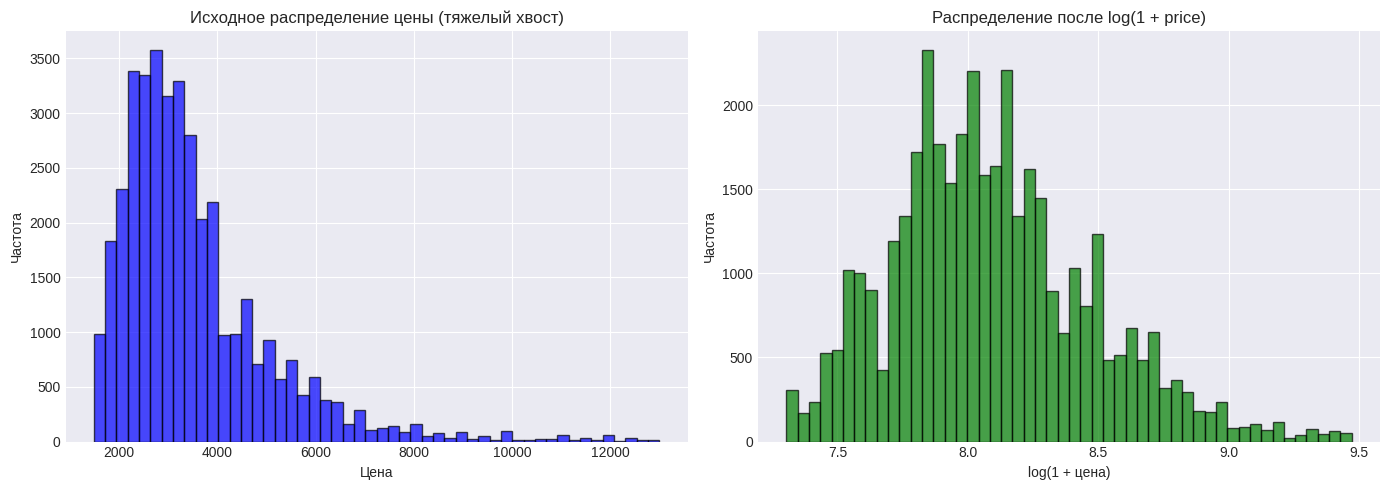


Статистика исходной цены:
  Среднее: 3535.82
  Медиана: 3150.00
  Стандартное отклонение: 1580.48
  Асимметрия: 1.9890

Статистика после log-трансформации:
  Среднее: 8.09
  Медиана: 8.06
  Стандартное отклонение: 0.38
  Асимметрия: 0.5884

ОБУЧЕНИЕ МОДЕЛЕЙ С LOG-ТРАНСФОРМАЦИЕЙ

Обучение моделей на log-трансформированной целевой переменной...

  Обучаем LinearRegression...
    Train - MAE: 694.82, RMSE: 1053.56, R2: 0.5556
    Test  - MAE: 698.25, RMSE: 1034.38, R2: 0.5852

  Обучаем Ridge...
    Train - MAE: 694.82, RMSE: 1053.56, R2: 0.5556
    Test  - MAE: 698.25, RMSE: 1034.38, R2: 0.5852

  Обучаем Lasso...
    Train - MAE: 719.75, RMSE: 1084.07, R2: 0.5295
    Test  - MAE: 723.81, RMSE: 1074.89, R2: 0.5521

  Обучаем ElasticNet...
    Train - MAE: 756.67, RMSE: 1152.69, R2: 0.4681
    Test  - MAE: 761.53, RMSE: 1155.15, R2: 0.4827


In [39]:
# BONUS
print("\n" + "=" * 80)
print("ЛОГАРИФМИЧЕСКАЯ ТРАНСФОРМАЦИЯ ЦЕЛЕВОЙ ПЕРЕМЕННОЙ")
print("=" * 80)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Исходное распределение
axes[0].hist(y_train, bins=50, edgecolor='black', alpha=0.7, color='blue')
axes[0].set_title('Исходное распределение цены (тяжелый хвост)')
axes[0].set_xlabel('Цена')
axes[0].set_ylabel('Частота')

# Логарифмическое распределение
y_train_log = np.log1p(y_train)  # log(1 + y)
axes[1].hist(y_train_log, bins=50, edgecolor='black', alpha=0.7, color='green')
axes[1].set_title('Распределение после log(1 + price)')
axes[1].set_xlabel('log(1 + цена)')
axes[1].set_ylabel('Частота')

plt.tight_layout()
plt.show()

print(f"\nСтатистика исходной цены:")
print(f"  Среднее: {y_train.mean():.2f}")
print(f"  Медиана: {y_train.median():.2f}")
print(f"  Стандартное отклонение: {y_train.std():.2f}")
print(f"  Асимметрия: {pd.Series(y_train).skew():.4f}")

print(f"\nСтатистика после log-трансформации:")
print(f"  Среднее: {y_train_log.mean():.2f}")
print(f"  Медиана: {np.median(y_train_log):.2f}")
print(f"  Стандартное отклонение: {y_train_log.std():.2f}")
print(f"  Асимметрия: {pd.Series(y_train_log).skew():.4f}")

print("\n" + "=" * 80)
print("ОБУЧЕНИЕ МОДЕЛЕЙ С LOG-ТРАНСФОРМАЦИЕЙ")
print("=" * 80)

X_train_np = np.array(X_train)
X_test_np = np.array(X_test)

# Логарифмируем целевую переменную
y_train_log = np.log1p(y_train)
y_test_log = np.log1p(y_test)

models_to_test = [
    ('LinearRegression', LinearRegression()),
    ('Ridge', Ridge(alpha=0.1, random_state=42)),
    ('Lasso', Lasso(alpha=0.01, random_state=42, max_iter=5000)),
    ('ElasticNet', ElasticNet(alpha=0.05, l1_ratio=0.5, random_state=42, max_iter=5000))
]

log_results = []

print("\nОбучение моделей на log-трансформированной целевой переменной...")

for name, model in models_to_test:
    print(f"\n  Обучаем {name}...")

    model.fit(X_train_np, y_train_log)

    # Предсказания в логарифмическом пространстве
    y_pred_log_train = model.predict(X_train_np)
    y_pred_log_test = model.predict(X_test_np)

    # Обратное преобразование (экспоненцирование)
    y_pred_train = np.expm1(y_pred_log_train)  # exp(x) - 1
    y_pred_test = np.expm1(y_pred_log_test)

    # Метрики на исходной шкале
    mae_train = mean_absolute_error(y_train, y_pred_train)
    mae_test = mean_absolute_error(y_test, y_pred_test)
    rmse_train = np.sqrt(mean_squared_error(y_train, y_pred_train))
    rmse_test = np.sqrt(mean_squared_error(y_test, y_pred_test))
    r2_train = r2_score(y_train, y_pred_train)
    r2_test = r2_score(y_test, y_pred_test)

    log_results.append({
        'model': f'{name}_log',
        'dataset': 'train',
        'MAE': mae_train,
        'RMSE': rmse_train,
        'R2': r2_train
    })
    log_results.append({
        'model': f'{name}_log',
        'dataset': 'test',
        'MAE': mae_test,
        'RMSE': rmse_test,
        'R2': r2_test
    })

    print(f"    Train - MAE: {mae_train:.2f}, RMSE: {rmse_train:.2f}, R2: {r2_train:.4f}")
    print(f"    Test  - MAE: {mae_test:.2f}, RMSE: {rmse_test:.2f}, R2: {r2_test:.4f}")

log_results_df = pd.DataFrame(log_results)



- Log-трансформация значительно уменьшила асимметрию с 1.99 до 0.59. Распределение стало более симметричным, что хорошо для линейных моделей
- Видим небольшое улучшение MAE (до 698.25), другие метрики слегка ухудшились
- Почему Lasso и ElasticNet стали хуже?
  
  L1-регуляризация (Lasso) обнуляет веса. После log-трансформации масштаб признаков изменился, и Lasso мог слишком сильно зарезать важные признаки.

  Двойное сжатие - L1 + log-трансформация могут слишком сильно упростить модель.

  Нестабильность - модели с регуляризацией чувствительны к изменению распределения целевой переменной.
- Log-трансформация полезна, но дает компромисс - улучшает MAE за счет небольшого ухудшения RMSE. Выбор зависит от бизнес-задачи: важнее ли средняя ошибка или штраф за очень большие ошибки.

In [43]:
# BONUS
print("\n" + "=" * 80)
print("АНАЛИТИЧЕСКОЕ РЕШЕНИЕ ЛИНЕЙНОЙ РЕГРЕССИИ (Normal Equation)")
print("=" * 80)

class LinearRegressionAnalytical:
    """
    Линейная регрессия с аналитическим решением
    Использует формулу нормального уравнения: w = (X^T X)^(-1) X^T y
    """

    def __init__(self, add_bias=True):
        self.add_bias = add_bias
        self.weights = None
        self.bias = None

    def _add_bias_column(self, X):
        if not self.add_bias:
            return X
        return np.c_[np.ones(X.shape[0]), X]

    def fit(self, X, y):
        """
        Обучение модели через аналитическое решение
        X: матрица признаков (n_samples, n_features)
        y: целевая переменная (n_samples,)
        """
        # Преобразуем в numpy массивы
        X = np.array(X)
        y = np.array(y).reshape(-1, 1)

        # Добавляем столбец единиц
        X_with_bias = self._add_bias_column(X)

        # Аналитическое решение: w = (X^T X)^(-1) X^T y
        # Шаг 1: X^T X
        XTX = X_with_bias.T @ X_with_bias

        # Шаг 2: (X^T X)^(-1) - обратная матрица
        XTX_inv = np.linalg.inv(XTX)

        # Шаг 3: X^T y
        XTy = X_with_bias.T @ y

        # Шаг 4: w = (X^T X)^(-1) X^T y
        weights_full = XTX_inv @ XTy

        # Разделяем bias и weights
        if self.add_bias:
            self.bias = weights_full[0][0]
            self.weights = weights_full[1:].flatten()
        else:
            self.weights = weights_full.flatten()
            self.bias = 0.0

        return self

    def predict(self, X):
        X = np.array(X)
        return X @ self.weights + self.bias


АНАЛИТИЧЕСКОЕ РЕШЕНИЕ ЛИНЕЙНОЙ РЕГРЕССИИ (Normal Equation)


In [44]:
print("\nОбучение модели с аналитическим решением...")

X_train_np = np.array(X_train)
X_test_np = np.array(X_test)

analytical_model = LinearRegressionAnalytical(add_bias=True)
analytical_model.fit(X_train_np, y_train)

y_train_pred_analytical = analytical_model.predict(X_train_np)
y_test_pred_analytical = analytical_model.predict(X_test_np)

mae_train_analytical = mean_absolute_error(y_train, y_train_pred_analytical)
mae_test_analytical = mean_absolute_error(y_test, y_test_pred_analytical)

rmse_train_analytical = np.sqrt(mean_squared_error(y_train, y_train_pred_analytical))
rmse_test_analytical = np.sqrt(mean_squared_error(y_test, y_test_pred_analytical))

r2_train_analytical = r2_score(y_train, y_train_pred_analytical)
r2_test_analytical = r2_score(y_test, y_test_pred_analytical)

print(f"\nРезультаты аналитического решения:")
print(f"  Train - MAE: {mae_train_analytical:.2f}, RMSE: {rmse_train_analytical:.2f}, R2: {r2_train_analytical:.4f}")
print(f"  Test  - MAE: {mae_test_analytical:.2f}, RMSE: {rmse_test_analytical:.2f}, R2: {r2_test_analytical:.4f}")


Обучение модели с аналитическим решением...

Результаты аналитического решения:
  Train - MAE: 708.49, RMSE: 1028.25, R2: 0.5767
  Test  - MAE: 709.68, RMSE: 1023.84, R2: 0.5936


In [45]:
print("\n" + "=" * 80)
print("СРАВНЕНИЕ РАЗЛИЧНЫХ РЕАЛИЗАЦИЙ ЛИНЕЙНОЙ РЕГРЕССИИ")
print("=" * 80)

comparison_results = []

comparison_results.append({
    'model': 'Analytical (Normal Equation)',
    'dataset': 'train',
    'MAE': mae_train_analytical,
    'RMSE': rmse_train_analytical,
    'R2': r2_train_analytical
})
comparison_results.append({
    'model': 'Analytical (Normal Equation)',
    'dataset': 'test',
    'MAE': mae_test_analytical,
    'RMSE': rmse_test_analytical,
    'R2': r2_test_analytical
})

comparison_results.append({
    'model': 'SGD Custom',
    'dataset': 'train',
    'MAE': mae_train_custom,
    'RMSE': rmse_train_custom,
    'R2': r2_train_custom
})
comparison_results.append({
    'model': 'SGD Custom',
    'dataset': 'test',
    'MAE': mae_test_custom,
    'RMSE': rmse_test_custom,
    'R2': r2_test_custom
})

comparison_results.append({
    'model': 'Sklearn LinearRegression',
    'dataset': 'train',
    'MAE': mae_train_sklearn,
    'RMSE': rmse_train_sklearn,
    'R2': r2_train_sklearn
})
comparison_results.append({
    'model': 'Sklearn LinearRegression',
    'dataset': 'test',
    'MAE': mae_test_sklearn,
    'RMSE': rmse_test_sklearn,
    'R2': r2_test_sklearn
})

comparison_df = pd.DataFrame(comparison_results)

test_comparison = comparison_df[comparison_df['dataset'] == 'test'].copy()
test_comparison = test_comparison[['model', 'MAE', 'RMSE', 'R2']].sort_values('RMSE')

print("\nСравнение на тестовой выборке:")
print("=" * 80)
print(test_comparison.to_string(index=False))


СРАВНЕНИЕ РАЗЛИЧНЫХ РЕАЛИЗАЦИЙ ЛИНЕЙНОЙ РЕГРЕССИИ

Сравнение на тестовой выборке:
                       model        MAE       RMSE       R2
    Sklearn LinearRegression 709.678526 1023.84289 0.593597
Analytical (Normal Equation) 709.678526 1023.84289 0.593597
                  SGD Custom 704.960024 1024.90987 0.592749


Analytical и Sklearn дают идентичные результаты (разница 0.0), что подтверждает корректность реализации. SGD Custom показывает близкие результаты (отклонение < 1%) и является хорошей альтернативой для больших данных.